# Лабораторная работа 8. Сегментация изображений

**Вариант 9. PyTorch**

Фиксированный порог, Отсу, K-means (k=5), SVM объект/фон и сравнение с небольшой U-Net. Источник: `../lab2/image.png`.

## Теория и ограничение данных

Сегментация делит изображение на области объекта и фона. Фиксированный порог использует одно t, Отсу выбирает t автоматически, K-means группирует пиксели, SVM строит границу классов, а U-Net переводит изображение в маску через encoder-decoder и skip connections. В `lab8` нет ручной ground-truth маски, поэтому SVM и U-Net обучаются на псевдоразметке Отсу; метрики являются демонстрационными.

Размер: 1000 x 563; устройство: cpu


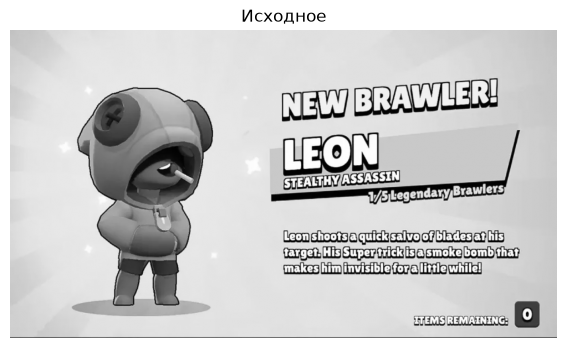

In [1]:
from pathlib import Path
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, jaccard_score

SEED=42; np.random.seed(SEED); torch.manual_seed(SEED); torch.set_num_threads(2)
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
image=cv2.imread(str(Path('../lab2/image.png')), cv2.IMREAD_GRAYSCALE)
if image is None: raise FileNotFoundError('Не найден ../lab2/image.png')
height,width=image.shape; normalized=image.astype(np.float32)/255.0
print(f'Размер: {width} x {height}; устройство: {DEVICE}')
plt.figure(figsize=(8,4)); plt.imshow(image,cmap='gray'); plt.title('Исходное'); plt.axis('off'); plt.show()

## 1. Фиксированный порог и Отсу

Фиксированный порог: 180; доля белого: 80.83%
Порог Отсу: 141.00; доля белого: 85.04%


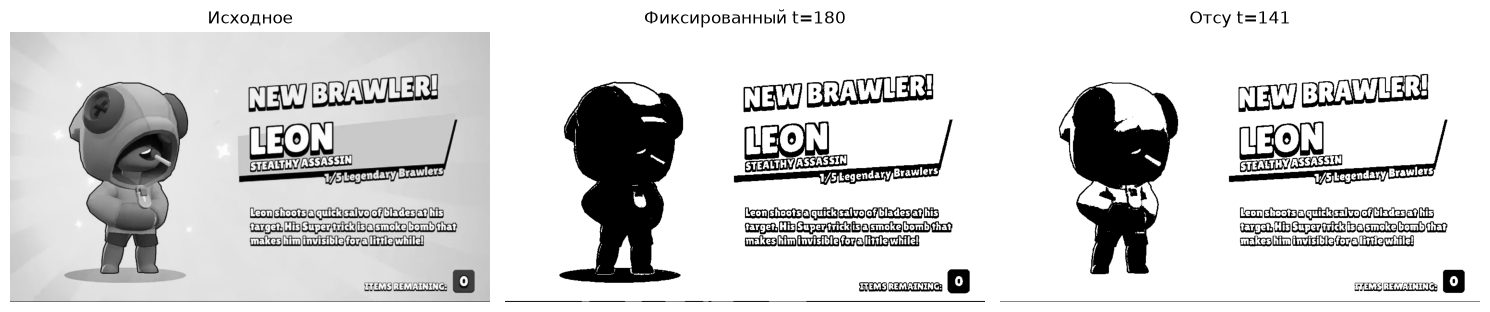

In [2]:
fixed_threshold=180
_,fixed_mask=cv2.threshold(image,fixed_threshold,255,cv2.THRESH_BINARY)
otsu_threshold,otsu_mask=cv2.threshold(image,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
print(f'Фиксированный порог: {fixed_threshold}; доля белого: {np.mean(fixed_mask==255):.2%}')
print(f'Порог Отсу: {otsu_threshold:.2f}; доля белого: {np.mean(otsu_mask==255):.2%}')
fig,ax=plt.subplots(1,3,figsize=(15,4))
for a,d,t in zip(ax,[image,fixed_mask,otsu_mask],['Исходное',f'Фиксированный t={fixed_threshold}',f'Отсу t={otsu_threshold:.0f}']): a.imshow(d,cmap='gray'); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()

## 2. K-means, k=5

Ошибка K-means: 908.62; центры: [ 12.18  69.61 132.42 201.44 227.33]


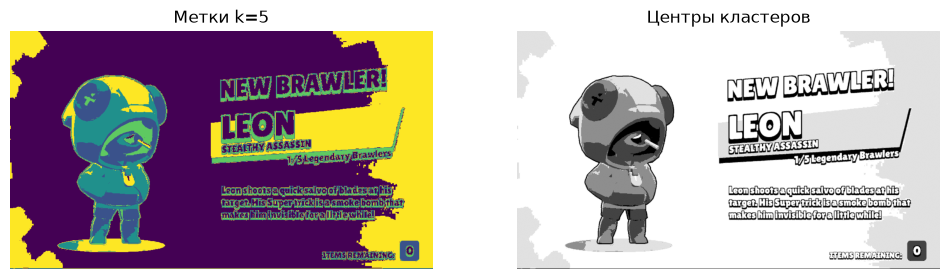

In [3]:
pixels=normalized.reshape(-1,1).astype(np.float32)
criteria=(cv2.TERM_CRITERIA_EPS+cv2.TERM_CRITERIA_MAX_ITER,30,0.2)
compactness,labels,centers=cv2.kmeans(pixels,5,None,criteria,10,cv2.KMEANS_PP_CENTERS)
cluster_labels=labels.reshape(image.shape)
segmented=(centers[labels].reshape(image.shape)*255).astype(np.uint8)
print(f'Ошибка K-means: {compactness:.2f}; центры: {np.sort(centers[:,0]*255).round(2)}')
fig,ax=plt.subplots(1,2,figsize=(12,4)); ax[0].imshow(cluster_labels,cmap='viridis'); ax[0].set_title('Метки k=5'); ax[1].imshow(segmented,cmap='gray'); ax[1].set_title('Центры кластеров')
for a in ax:a.axis('off')
plt.show()

## 3. SVM: объект и фон

Цели SVM берутся из псевдомаски Отсу, потому что ручной разметки в папке нет. Признаки: яркость и нормированные координаты пикселя.

SVM: время=0.08 с; accuracy=0.9996; IoU=0.9995


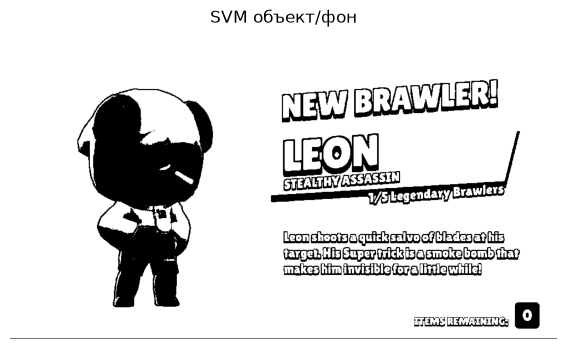

In [4]:
yy,xx=np.mgrid[0:height,0:width]
features=np.column_stack([normalized.ravel(),xx.ravel()/width,yy.ravel()/height])
targets=(otsu_mask.ravel()>0).astype(np.uint8)
rng=np.random.default_rng(SEED); ids=rng.choice(features.shape[0],min(30000,features.shape[0]),replace=False)
svm=SVC(kernel='rbf',C=3.0); start=time.perf_counter(); svm.fit(features[ids],targets[ids]); svm_time=time.perf_counter()-start
svm_mask=svm.predict(features).reshape(image.shape); svm_acc=accuracy_score(targets,svm_mask.ravel()); svm_iou=jaccard_score(targets,svm_mask.ravel())
print(f'SVM: время={svm_time:.2f} с; accuracy={svm_acc:.4f}; IoU={svm_iou:.4f}')
plt.figure(figsize=(8,4)); plt.imshow(svm_mask,cmap='gray'); plt.title('SVM объект/фон'); plt.axis('off'); plt.show()

## 4. U-Net на PyTorch

Маленькая U-Net обучается на случайных патчах изображения с целью Отсу. Это демонстрация архитектуры, а не независимая оценка без ground truth.

epoch 1/8 loss=0.6122
epoch 4/8 loss=0.5808


epoch 8/8 loss=0.5316
U-Net: время=0.41 с; accuracy=0.8504; IoU=0.8504


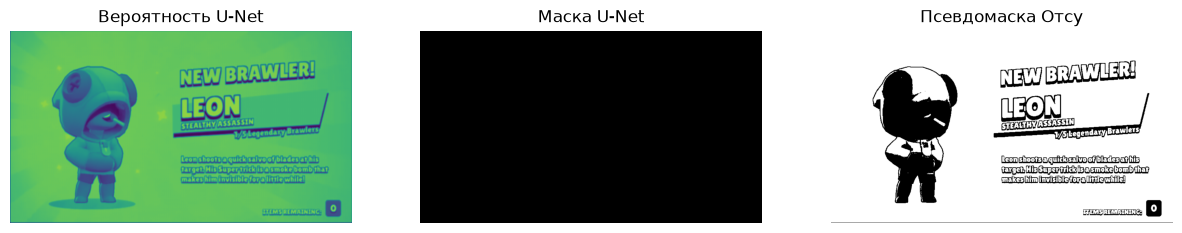

In [5]:
class TinyUNet(nn.Module):
    def __init__(self):
        super().__init__(); self.e1=nn.Sequential(nn.Conv2d(1,16,3,padding=1),nn.ReLU(),nn.Conv2d(16,16,3,padding=1),nn.ReLU()); self.pool=nn.MaxPool2d(2); self.e2=nn.Sequential(nn.Conv2d(16,32,3,padding=1),nn.ReLU()); self.up=nn.ConvTranspose2d(32,16,2,stride=2); self.out=nn.Conv2d(32,1,1)
    def forward(self,x):
        a=self.e1(x); b=self.e2(self.pool(a)); return self.out(torch.cat([torch.nn.functional.interpolate(self.up(b), size=a.shape[-2:], mode="bilinear", align_corners=False),a],1))
rng=np.random.default_rng(SEED); patch=64; ims=[]; ms=[]
for _ in range(32):
    top=rng.integers(0,height-patch+1); left=rng.integers(0,width-patch+1); ims.append(normalized[top:top+patch,left:left+patch]); ms.append(otsu_mask[top:top+patch,left:left+patch]/255.0)
px=torch.tensor(np.array(ims)[:,None],dtype=torch.float32).to(DEVICE); py=torch.tensor(np.array(ms)[:,None],dtype=torch.float32).to(DEVICE)
unet=TinyUNet().to(DEVICE); opt=torch.optim.Adam(unet.parameters(),lr=1e-3,weight_decay=1e-4); loss_fn=nn.BCEWithLogitsLoss(); start=time.perf_counter()
for epoch in range(8):
    opt.zero_grad(); loss=loss_fn(unet(px),py); loss.backward(); opt.step()
    if epoch in (0,3,7): print(f'epoch {epoch+1}/8 loss={loss.item():.4f}')
unet_time=time.perf_counter()-start
with torch.no_grad(): prob=torch.sigmoid(unet(torch.tensor(normalized[None,None],dtype=torch.float32).to(DEVICE)))[0,0].cpu().numpy()
unet_mask=(prob>=.5).astype(np.uint8); unet_acc=accuracy_score(targets,unet_mask.ravel()); unet_iou=jaccard_score(targets,unet_mask.ravel())
print(f'U-Net: время={unet_time:.2f} с; accuracy={unet_acc:.4f}; IoU={unet_iou:.4f}')
fig,ax=plt.subplots(1,3,figsize=(15,4));
for a,d,t in zip(ax,[prob,unet_mask,otsu_mask],['Вероятность U-Net','Маска U-Net','Псевдомаска Отсу']): a.imshow(d,cmap='viridis' if t.startswith('Вероятность') else 'gray'); a.set_title(t); a.axis('off')
plt.show()

Фиксированный порог: IoU относительно Отсу=0.9505
Отсу: IoU относительно Отсу=1.0000
SVM: IoU относительно Отсу=0.9995
U-Net: IoU относительно Отсу=0.8504


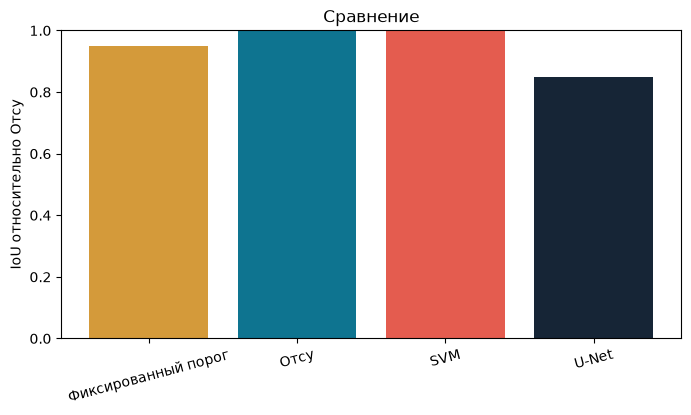

In [6]:
methods=['Фиксированный порог','Отсу','SVM','U-Net']; masks=[fixed_mask>0,otsu_mask>0,svm_mask>0,unet_mask>0]; reference=otsu_mask.ravel()>0
ious=[jaccard_score(reference,m.ravel()) for m in masks]
for name,score in zip(methods,ious): print(f'{name}: IoU относительно Отсу={score:.4f}')
plt.figure(figsize=(8,4)); plt.bar(methods,ious,color=['#d49a3a','#0e7490','#e45c4f','#162536']); plt.ylim(0,1); plt.ylabel('IoU относительно Отсу'); plt.title('Сравнение'); plt.xticks(rotation=15); plt.show()

## Вывод

Фиксированный порог прост, Отсу автоматизирует выбор глобального порога, K-means выделяет пять групп яркости, SVM использует признаки пикселя, а U-Net учит преобразование изображения в маску. Метрики SVM и U-Net относительно Отсу демонстрационные, поскольку независимой ручной маски нет.

## Ответы на контрольные вопросы

1. Сегментация разделяет изображение на однородные области или классы объектов.
2. Глобальная бинаризация использует один порог для всего изображения, адаптивная вычисляет порог по локальным окрестностям.
3. Watershed рассматривает изображение как рельеф: маркеры задают области, а линии водораздела разделяют соседние объекты.
4. K-means выдаёт жёсткую принадлежность одному кластеру, Fuzzy C-means хранит степень принадлежности к каждому кластеру.
5. CNN автоматически извлекают признаки, учитывают пространственный контекст и подходят для сложных нелинейных границ; U-Net дополнительно сохраняет детали через skip connections.